# 032 — Repeated splits using the exact notebook-03 target logic

This notebook repeats the ZeBRA / genomic / combined comparison over many randomized
train/test partitions while preserving the target construction used by
`03_COMBINED_CLASSIFIERS.ipynb`.

## Exact target logic copied from 03

For each target, notebook 03:

1. starts from `ILD_TOP_DRIVERS_DATA.csv`;
2. left-merges the rephenotype table;
3. converts the target to numeric;
4. assigns **missing target values to 0**;
5. left-merges ZeBRA `predicted_risk`;
6. retains rows with non-missing `predicted_risk`.

Thus blank target cells are treated as controls. This is essential for reproducing
the ~0.80 ZeBRA AUC reported by notebook 03.

## Models

For every randomized outer split:

- **ZeBRA:** raw `predicted_risk` → ROC/AUC directly. No classifier.
- **Genomic:** LightGBM using genomic features only.
- **Combined:** LightGBM using genomic features + `predicted_risk`.

The outer split uses 40% train / 60% held-out test, matching notebook 03.

For the two learned models only, hyperparameter selection is done by inner stratified
cross-validation inside the 40% training partition. ZeBRA is never fitted or tuned.

## SHAP

SHAP is computed on each outer-test partition for the genomic and combined models.
Split-level mean absolute SHAP values are aggregated to obtain mean, median, maximum,
empirical split bounds, and bootstrap confidence bounds.

## zedstat extension

This version also runs the `zedstat` package on every held-out score vector.
It saves complete threshold-level operating-characteristic tables with analytic
confidence bounds, zedstat AUC, calibration statistics, reliability tables,
and standardized operating-point summaries.


In [1]:
import os
import json
import secrets
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterSampler
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

from zedstat import zedstat
from zedstat import calibration

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
%matplotlib inline

N_REPEATS = 10
TRAIN_SIZE = 0.40
INNER_CV_FOLDS = 3
N_PARAM_TRIALS = 12

MAX_SHAP_PATIENTS = 2000
N_SHAP_BOOT = 1000
PARTIAL_AUC_MAX_FPR = 0.05

# ------------------------------------------------------------------
# zedstat performance / calibration controls
# ------------------------------------------------------------------
ZEDSTAT_ALPHA = 0.05
ZEDSTAT_ORDER = 3
ZEDSTAT_STEPS = 1000
ZEDSTAT_SMOOTH_STEP = 0.001
ZEDSTAT_PRECISION = 3
ZEDSTAT_LR_FPR_FLOOR = 0.001
ZEDSTAT_CALIBRATION_BINS = 10

# None => use the observed prevalence in each held-out outer-test split.
# Set to a deployment prevalence if PPV/NPV should be standardized externally.
ZEDSTAT_TARGET_PREVALENCE = None

# Standardized operating points extracted from the full zedstat table.
ZEDSTAT_OPERATING_FPRS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]

BASE_DATA_FILE = "ILD_TOP_DRIVERS_DATA.csv"
TARGET_FILE = "REPHENOTYPES FOR IC.csv"
PRED_FILE = "PREDICTIONS_52W_PRED_WINDOW.parquet"

ROOT_OUT = Path("./RESULTS/32_REPEATED_SPLITS_03_TARGET_LOGIC_NOT_032")
ROOT_OUT.mkdir(parents=True, exist_ok=True)

print("Train fraction:", TRAIN_SIZE)
print("Test fraction:", 1 - TRAIN_SIZE)
print("Repeats:", N_REPEATS)
print("zedstat module:", zedstat.__file__)
print("zedstat calibration module:", calibration.__file__)


Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


Train fraction: 0.4
Test fraction: 0.6
Repeats: 10
zedstat module: /project/ich248_uksr/DMYTRO/.codebase/anaconda_mcc/envs/salus2/lib/python3.10/site-packages/zedstat/zedstat.py
zedstat calibration module: /project/ich248_uksr/DMYTRO/.codebase/anaconda_mcc/envs/salus2/lib/python3.10/site-packages/zedstat/calibration.py


## Helper functions

In [2]:
def raw_partial_auc(y_true, score, max_fpr=0.05):
    fpr, tpr, _ = roc_curve(y_true, score, drop_intermediate=False)
    keep = fpr < max_fpr
    fk, tk = fpr[keep], tpr[keep]
    t_at = np.interp(max_fpr, fpr, tpr)
    fk = np.r_[fk, max_fpr]
    tk = np.r_[tk, t_at]
    return float(np.trapz(tk, fk))


def auc_record(target_name, repeat, split_seed, model_name, y_true, score):
    return {
        "target_name": target_name,
        "repeat": repeat,
        "split_seed": int(split_seed),
        "model": model_name,
        "n_test": int(len(y_true)),
        "n_pos_test": int(np.asarray(y_true).sum()),
        "auc": float(roc_auc_score(y_true, score)),
        "partial_auc_fpr_0_05_raw": raw_partial_auc(
            y_true, score, PARTIAL_AUC_MAX_FPR
        ),
        "average_precision": float(
            average_precision_score(y_true, score)
        ),
    }


def parameter_space():
    return {
        "n_estimators": [50, 100, 200, 400, 700],
        "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.12],
        "num_leaves": [7, 15, 31, 63, 127],
        "max_depth": [-1, 3, 5, 7, 10, 14],
        "min_child_samples": [10, 20, 40, 80, 150],
        "subsample": [0.60, 0.75, 0.90, 1.0],
        "colsample_bytree": [0.40, 0.60, 0.80, 1.0],
        "reg_alpha": [0.0, 0.01, 0.10, 0.50, 1.0],
        "reg_lambda": [0.0, 0.10, 0.50, 1.0, 5.0],
        "min_split_gain": [0.0, 0.01, 0.10, 0.50],
        "max_bin": [63, 127, 255, 511],
    }


def fit_lgbm_inner_cv(X, y, param_seed, cv_seed, model_seed):
    X = X.reset_index(drop=True)
    y = np.asarray(y).astype(int)

    cv = StratifiedKFold(
        n_splits=INNER_CV_FOLDS,
        shuffle=True,
        random_state=int(cv_seed),
    )
    folds = list(cv.split(X, y))

    trials = ParameterSampler(
        parameter_space(),
        n_iter=N_PARAM_TRIALS,
        random_state=int(param_seed),
    )

    best_auc = -np.inf
    best_params = None

    for params in trials:
        fold_aucs = []

        for fi, (tr, va) in enumerate(folds):
            yy = y[tr]
            n_pos = max(int((yy == 1).sum()), 1)
            n_neg = max(int((yy == 0).sum()), 1)
            spw = n_neg / n_pos

            m = LGBMClassifier(
                **params,
                objective="binary",
                scale_pos_weight=spw,
                subsample_freq=1,
                n_jobs=-1,
                random_state=(int(model_seed) + fi + 1) % (2**31 - 1),
                verbosity=-1,
            )
            m.fit(X.iloc[tr], yy)
            p = m.predict_proba(X.iloc[va])[:, 1]
            fold_aucs.append(roc_auc_score(y[va], p))

        cv_auc = float(np.mean(fold_aucs))

        if cv_auc > best_auc:
            best_auc = cv_auc
            best_params = dict(params)

    n_pos = max(int((y == 1).sum()), 1)
    n_neg = max(int((y == 0).sum()), 1)

    final = LGBMClassifier(
        **best_params,
        objective="binary",
        scale_pos_weight=n_neg / n_pos,
        subsample_freq=1,
        n_jobs=-1,
        random_state=int(model_seed),
        verbosity=-1,
    )
    final.fit(X, y)

    return final, best_params, best_auc


def positive_class_shap(model, X):
    exp = shap.TreeExplainer(model)

    try:
        v = exp.shap_values(X, check_additivity=False)
    except TypeError:
        v = exp.shap_values(X)

    if isinstance(v, list):
        v = v[1] if len(v) > 1 else v[0]

    v = np.asarray(v)

    if v.ndim == 3:
        if v.shape[-1] == 2:
            v = v[:, :, 1]
        elif v.shape[0] == 2:
            v = v[1]

    if v.shape != X.shape:
        raise ValueError(f"Unexpected SHAP shape {v.shape}; X shape {X.shape}")

    return v


def split_shap(model, X_test, target, repeat, split_seed, model_name):
    sample_seed = secrets.randbits(31)
    Xs = X_test.sample(
        n=min(MAX_SHAP_PATIENTS, len(X_test)),
        random_state=sample_seed,
    )
    v = positive_class_shap(model, Xs)

    return pd.DataFrame({
        "target_name": target,
        "repeat": repeat,
        "split_seed": int(split_seed),
        "model": model_name,
        "feature": Xs.columns,
        "mean_abs_shap": np.abs(v).mean(axis=0),
        "n_shap_patients": len(Xs),
    })


def auc_summary(df):
    return (
        df.groupby(["target_name", "model"])["auc"]
        .agg(
            n_repeats="size",
            mean="mean",
            sd="std",
            median="median",
            min="min",
            max="max",
        )
        .reset_index()
    )


def shap_summary(df):
    rng = np.random.default_rng()
    rows = []

    for (target, model, feature), sub in df.groupby(
        ["target_name", "model", "feature"], sort=False
    ):
        x = sub["mean_abs_shap"].dropna().to_numpy(float)
        if len(x) == 0:
            continue

        boot_mean = np.empty(N_SHAP_BOOT)
        boot_max = np.empty(N_SHAP_BOOT)

        for b in range(N_SHAP_BOOT):
            xb = rng.choice(x, len(x), replace=True)
            boot_mean[b] = xb.mean()
            boot_max[b] = xb.max()

        rows.append({
            "target_name": target,
            "model": model,
            "feature": feature,
            "n_splits": len(x),
            "mean_importance": x.mean(),
            "median_importance": np.median(x),
            "max_importance": x.max(),
            "empirical_q025": np.quantile(x, 0.025),
            "empirical_q975": np.quantile(x, 0.975),
            "bootstrap_mean_ci_low": np.quantile(boot_mean, 0.025),
            "bootstrap_mean_ci_high": np.quantile(boot_mean, 0.975),
            "bootstrap_max_ci_low": np.quantile(boot_max, 0.025),
            "bootstrap_max_ci_high": np.quantile(boot_max, 0.975),
        })

    return pd.DataFrame(rows)

# =====================================================================
# zedstat evaluation helpers
# =====================================================================

def zedstat_evaluate_score(
    y_true,
    score,
    target_name,
    repeat,
    split_seed,
    model_name,
):
    """
    Evaluate one held-out score vector using zedstat.

    Returns
    -------
    summary : dict
        One-row model/split summary including AUC + CI and calibration.
    perf_df : pandas.DataFrame
        Full threshold-level zedstat operating-characteristics table,
        including analytic bounds.
    cal_df : pandas.DataFrame
        zedstat calibration/reliability table.
    """
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score, dtype=float)

    valid = np.isfinite(score) & np.isfinite(y_true)
    y_true = y_true[valid]
    score = score[valid]

    if np.unique(y_true).size < 2:
        raise ValueError(
            f"{target_name} / {model_name} / repeat {repeat}: "
            "both classes are required for zedstat evaluation."
        )

    eval_df = pd.DataFrame({
        "score": score,
        "target": y_true,
    })

    observed_prevalence = float(y_true.mean())
    prevalence_for_metrics = (
        observed_prevalence
        if ZEDSTAT_TARGET_PREVALENCE is None
        else float(ZEDSTAT_TARGET_PREVALENCE)
    )

    # --------------------------------------------------------------
    # Build ROC using zedstat and compute all operating measures.
    # --------------------------------------------------------------
    roc_df, total_samples, positive_samples = zedstat.genroc(
        eval_df,
        risk="score",
        target="target",
        steps=ZEDSTAT_STEPS,
        TARGET=[1],
    )

    zt = zedstat.processRoc(
        df=roc_df,
        order=ZEDSTAT_ORDER,
        total_samples=total_samples,
        positive_samples=positive_samples,
        alpha=ZEDSTAT_ALPHA,
        prevalence=prevalence_for_metrics,
        lr_fpr_floor=ZEDSTAT_LR_FPR_FLOOR,
    )

    # Keep empirical shape: do not convexify.
    zt.smooth(
        STEP=ZEDSTAT_SMOOTH_STEP,
        convexify=False,
    )
    zt.allmeasures(
        prevalence=prevalence_for_metrics,
        interpolate=True,
    )
    zt.usample(
        precision=ZEDSTAT_PRECISION,
    )
    zt.getBounds(
        total_samples=total_samples,
        positive_samples=positive_samples,
        alpha=ZEDSTAT_ALPHA,
        prevalence=prevalence_for_metrics,
    )

    nominal = zt.get()

    perf_df = (
        nominal
        .join(
            zt.df_lim["U"],
            rsuffix="_upper",
        )
        .join(
            zt.df_lim["L"],
            rsuffix="_lower",
        )
    )

    # zedstat may return FPR both as the dataframe index name and as
    # a regular column. In that case reset_index() would try to insert
    # a second "fpr" column and pandas raises:
    #   ValueError: cannot insert fpr, already exists
    #
    # Preserve the explicit zedstat fpr column and discard only the
    # redundant index representation.
    if (
        perf_df.index.name is not None
        and perf_df.index.name in perf_df.columns
    ):
        perf_df = perf_df.reset_index(drop=True)
    else:
        perf_df = perf_df.reset_index()

    if "fpr" not in perf_df.columns:
        raise RuntimeError(
            "zedstat performance table unexpectedly lacks an fpr column."
        )

    if perf_df.columns.duplicated().any():
        dup_cols = perf_df.columns[
            perf_df.columns.duplicated()
        ].tolist()
        raise RuntimeError(
            f"zedstat performance table contains duplicate columns: {dup_cols}"
        )

    # zedstat AUC and analytic Hanley-McNeil confidence interval.
    # zedstat returns (nominal, upper, lower).
    auc_nominal, auc_upper, auc_lower = zt.auc(
        total_samples=total_samples,
        positive_samples=positive_samples,
        alpha=ZEDSTAT_ALPHA,
        bootstrap=False,
    )

    # --------------------------------------------------------------
    # zedstat calibration assessment of the raw held-out probabilities.
    # --------------------------------------------------------------
    score_is_probability = bool(
        np.all((score >= 0.0) & (score <= 1.0))
    )

    if score_is_probability:
        cal_intercept, cal_slope = (
            calibration.calibration_intercept_slope(
                y_true,
                score,
            )
        )

        cal_df = calibration.calibration_table(
            prob=score,
            y=y_true,
            n_bins=ZEDSTAT_CALIBRATION_BINS,
            alpha=ZEDSTAT_ALPHA,
        )

        brier = float(
            np.mean(
                (score - y_true) ** 2
            )
        )

        cal_abs_error = (
            cal_df["obs_rate"]
            - cal_df["mean_pred"]
        ).abs()

        ece = float(
            np.average(
                cal_abs_error,
                weights=cal_df["n"],
            )
        )
        max_cal_error = float(
            cal_abs_error.max()
        )
        mean_predicted_risk = float(
            score.mean()
        )
        observed_to_expected = (
            observed_prevalence / mean_predicted_risk
            if mean_predicted_risk > 0
            else np.nan
        )
    else:
        cal_intercept = np.nan
        cal_slope = np.nan
        brier = np.nan
        ece = np.nan
        max_cal_error = np.nan
        mean_predicted_risk = np.nan
        observed_to_expected = np.nan
        cal_df = pd.DataFrame()

    # Annotate every threshold row so all splits/models can be concatenated.
    perf_df.insert(0, "model", model_name)
    perf_df.insert(0, "split_seed", int(split_seed))
    perf_df.insert(0, "repeat", int(repeat))
    perf_df.insert(0, "target_name", target_name)

    if "tpr" in perf_df.columns:
        perf_df["sensitivity"] = perf_df["tpr"]
    if "fpr" in perf_df.columns:
        perf_df["specificity"] = 1.0 - perf_df["fpr"]

    if len(cal_df):
        cal_df = cal_df.copy()
        cal_df.insert(0, "model", model_name)
        cal_df.insert(0, "split_seed", int(split_seed))
        cal_df.insert(0, "repeat", int(repeat))
        cal_df.insert(0, "target_name", target_name)

    summary = {
        "target_name": target_name,
        "repeat": int(repeat),
        "split_seed": int(split_seed),
        "model": model_name,
        "n_test": int(total_samples),
        "n_positive": int(positive_samples),
        "n_negative": int(total_samples - positive_samples),
        "observed_prevalence": observed_prevalence,
        "performance_prevalence": prevalence_for_metrics,

        "zedstat_auc": float(auc_nominal),
        "zedstat_auc_ci_low": float(auc_lower),
        "zedstat_auc_ci_high": float(auc_upper),

        "brier_score": brier,
        "calibration_intercept": float(cal_intercept)
            if np.isfinite(cal_intercept) else np.nan,
        "calibration_slope": float(cal_slope)
            if np.isfinite(cal_slope) else np.nan,
        "expected_calibration_error": ece,
        "max_calibration_error": max_cal_error,
        "mean_predicted_risk": mean_predicted_risk,
        "observed_to_expected_ratio": observed_to_expected,
    }

    return summary, perf_df, cal_df


def extract_zedstat_operating_points(
    perf_df,
    requested_fprs=ZEDSTAT_OPERATING_FPRS,
):
    """
    Extract nearest rows from a full zedstat operating table at
    standardized FPR values.
    """
    if len(perf_df) == 0:
        return pd.DataFrame()

    if "fpr" not in perf_df.columns:
        raise ValueError(
            "zedstat performance table does not contain an fpr column."
        )

    rows = []

    for requested_fpr in requested_fprs:
        distance = (
            perf_df["fpr"].astype(float)
            - float(requested_fpr)
        ).abs()

        row = perf_df.loc[
            distance.idxmin()
        ].copy()

        row["requested_fpr"] = float(
            requested_fpr
        )
        row["fpr_distance"] = float(
            distance.min()
        )

        rows.append(row)

    return pd.DataFrame(rows)


def summarize_repeated_metric(
    df,
    metric_columns,
    group_columns=("target_name", "model"),
):
    """
    Distribution summary over repeated outer splits.
    """
    rows = []

    for keys, sub in df.groupby(
        list(group_columns),
        sort=False,
    ):
        if not isinstance(keys, tuple):
            keys = (keys,)

        base = dict(
            zip(
                group_columns,
                keys,
            )
        )

        for metric in metric_columns:
            if metric not in sub.columns:
                continue

            x = pd.to_numeric(
                sub[metric],
                errors="coerce",
            ).dropna().to_numpy(dtype=float)

            if len(x) == 0:
                continue

            rows.append({
                **base,
                "metric": metric,
                "n_repeats": int(len(x)),
                "mean": float(np.mean(x)),
                "sd": float(np.std(x, ddof=1))
                    if len(x) > 1 else np.nan,
                "median": float(np.median(x)),
                "q025": float(np.quantile(x, 0.025)),
                "q975": float(np.quantile(x, 0.975)),
                "min": float(np.min(x)),
                "max": float(np.max(x)),
            })

    return pd.DataFrame(rows)


## Load the same inputs as notebook 03

In [3]:
BASE_DATA = pd.read_csv(BASE_DATA_FILE).drop(
    columns=["target"], errors="ignore"
)

NEW_TARGETS = (
    pd.read_csv(TARGET_FILE)
    .replace({"N": 0, "Y": 1, "y": 1, "n": 0, "na": np.nan})
    .rename(columns={"arb_person_id": "patient_id"})
)

PREDS = pd.read_parquet(PRED_FILE)

TARGET_NAMES = [
    c for c in NEW_TARGETS.columns
    if c != "patient_id"
]

print("BASE_DATA rows:", len(BASE_DATA))
print("Prediction rows:", len(PREDS))
print("Prediction unique patients:", PREDS["patient_id"].nunique())
print("Prediction duplicate rows beyond first:", PREDS["patient_id"].duplicated().sum())

print("\nTargets:")
for t in TARGET_NAMES:
    print(" -", t)

BASE_DATA rows: 19651
Prediction rows: 19519
Prediction unique patients: 12882
Prediction duplicate rows beyond first: 6636

Targets:
 - FILD or FILA ADJUDICATED
 - NONFIBROTIC ILD ADJUDICATED
 - NON FIBROTIC ILA ADJUDICATED


## Verify exact notebook-03 target construction

The critical lines below intentionally mirror notebook 03:

```python
DATA["target"] = pd.to_numeric(DATA["target"], errors="coerce").fillna(0).astype(int)
DATA = DATA[DATA["predicted_risk"].notnull()].copy()
```

The sanity split uses `random_state=1321` and should reproduce the ZeBRA result from 03.

In [4]:
SANITY = []

for TARGET_NAME in TARGET_NAMES:

    DATA = (
        BASE_DATA
        .merge(
            NEW_TARGETS[["patient_id", TARGET_NAME]].rename(
                columns={TARGET_NAME: "target"}
            ),
            on="patient_id",
            how="left",
        )
        .merge(
            PREDS[["patient_id", "predicted_risk"]],
            on="patient_id",
            how="left",
        )
    )

    # EXACT NOTEBOOK-03 TARGET LOGIC
    DATA["target"] = (
        pd.to_numeric(DATA["target"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    # EXACT NOTEBOOK-03 FILTER
    DATA = DATA[
        DATA["predicted_risk"].notnull()
    ].copy()

    X = DATA.drop(columns=["patient_id", "target"])
    y = DATA["target"]

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        train_size=0.40,
        stratify=y,
        random_state=1321,
    )

    auc03 = roc_auc_score(
        y_val,
        X_val["predicted_risk"],
    )

    SANITY.append({
        "target_name": TARGET_NAME,
        "n_total": len(DATA),
        "n_positive_total": int(y.sum()),
        "n_validation": len(y_val),
        "n_positive_validation": int(y_val.sum()),
        "zebra_auc_exact_03_split": float(auc03),
    })

SANITY = pd.DataFrame(SANITY)
SANITY.to_csv(
    ROOT_OUT / "sanity_exact_03_target_logic.csv",
    index=False,
)

display(SANITY)

,target_name,n_total,n_positive_total,n_validation,n_positive_validation,zebra_auc_exact_03_split
0,FILD or FILA ADJUDICATED,12882,271,7730,163,0.835301
1,NONFIBROTIC ILD ADJUDICATED,12882,30,7730,18,0.871571
2,NON FIBROTIC ILA ADJUDICATED,12882,77,7730,46,0.840895


## Repeated randomized outer splits

No fixed split seed is used. Every repeat saves the entropy-generated seed used for
the outer split.

In [5]:
ALL_AUC = []
ALL_SHAP = []
ALL_PARAMS = []
ALL_ZEDSTAT_SUMMARY = []
ALL_ZEDSTAT_PERFORMANCE = []
ALL_ZEDSTAT_CALIBRATION = []
ALL_ZEDSTAT_OPERATING_POINTS = []

for TARGET_NAME in TARGET_NAMES:

    print("\n" + "=" * 110)
    print(TARGET_NAME)
    print("=" * 110)

    TDIR = ROOT_OUT / TARGET_NAME
    TDIR.mkdir(parents=True, exist_ok=True)

    DATA = (
        BASE_DATA
        .merge(
            NEW_TARGETS[["patient_id", TARGET_NAME]].rename(
                columns={TARGET_NAME: "target"}
            ),
            on="patient_id",
            how="left",
        )
        .merge(
            PREDS[["patient_id", "predicted_risk"]],
            on="patient_id",
            how="left",
        )
    )

    # EXACT NOTEBOOK-03 TARGET LOGIC
    DATA["target"] = (
        pd.to_numeric(DATA["target"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    # EXACT NOTEBOOK-03 FILTER
    DATA = DATA[
        DATA["predicted_risk"].notnull()
    ].copy()

    X_combined = DATA.drop(columns=["patient_id", "target"])
    X_genomic = X_combined.drop(columns=["predicted_risk"])
    y = DATA["target"].to_numpy()

    print(
        f"N={len(DATA):,}; positives={y.sum():,}; "
        f"genomic features={X_genomic.shape[1]:,}"
    )

    target_auc = []
    target_shap_frames = []

    for repeat in tqdm(
        range(1, N_REPEATS + 1),
        desc=f"{TARGET_NAME}: repeats",
    ):
        split_seed = secrets.randbits(31)
        cv_seed = secrets.randbits(31)

        tr, te = train_test_split(
            np.arange(len(DATA)),
            train_size=TRAIN_SIZE,
            stratify=y,
            random_state=split_seed,
        )

        yt = y[tr]
        ye = y[te]

        Xgt = X_genomic.iloc[tr]
        Xge = X_genomic.iloc[te]

        Xct = X_combined.iloc[tr]
        Xce = X_combined.iloc[te]

        # ZeBRA: DIRECT raw score. No LightGBM.
        zebra_score = Xce["predicted_risk"].to_numpy(dtype=float)

        genomic_model, gp, gcv = fit_lgbm_inner_cv(
            Xgt,
            yt,
            param_seed=secrets.randbits(31),
            cv_seed=cv_seed,
            model_seed=secrets.randbits(31),
        )

        combined_model, cp, ccv = fit_lgbm_inner_cv(
            Xct,
            yt,
            param_seed=secrets.randbits(31),
            cv_seed=cv_seed,
            model_seed=secrets.randbits(31),
        )

        genomic_score = genomic_model.predict_proba(Xge)[:, 1]
        combined_score = combined_model.predict_proba(Xce)[:, 1]

        # ----------------------------------------------------------
        # Full zedstat evaluation on the identical held-out patients
        # ----------------------------------------------------------
        zedstat_scores = {
            "zebra": zebra_score,
            "genomic": genomic_score,
            "combined": combined_score,
        }

        repeat_zedstat_summary = []
        repeat_zedstat_perf = []
        repeat_zedstat_cal = []
        repeat_zedstat_ops = []

        for z_model_name, z_score in zedstat_scores.items():
            z_summary, z_perf, z_cal = zedstat_evaluate_score(
                y_true=ye,
                score=z_score,
                target_name=TARGET_NAME,
                repeat=repeat,
                split_seed=split_seed,
                model_name=z_model_name,
            )

            # retain sklearn AUC beside zedstat AUC as a numerical check
            z_summary["sklearn_auc_check"] = float(
                roc_auc_score(
                    ye,
                    z_score,
                )
            )
            z_summary["auc_zedstat_minus_sklearn"] = (
                z_summary["zedstat_auc"]
                - z_summary["sklearn_auc_check"]
            )

            repeat_zedstat_summary.append(
                z_summary
            )
            repeat_zedstat_perf.append(
                z_perf
            )

            if len(z_cal):
                repeat_zedstat_cal.append(
                    z_cal
                )

            z_ops = extract_zedstat_operating_points(
                z_perf
            )
            if len(z_ops):
                repeat_zedstat_ops.append(
                    z_ops
                )

        ALL_ZEDSTAT_SUMMARY.extend(
            repeat_zedstat_summary
        )
        ALL_ZEDSTAT_PERFORMANCE.extend(
            repeat_zedstat_perf
        )
        ALL_ZEDSTAT_CALIBRATION.extend(
            repeat_zedstat_cal
        )
        ALL_ZEDSTAT_OPERATING_POINTS.extend(
            repeat_zedstat_ops
        )

        recs = [
            auc_record(
                TARGET_NAME, repeat, split_seed,
                "zebra", ye, zebra_score
            ),
            auc_record(
                TARGET_NAME, repeat, split_seed,
                "genomic", ye, genomic_score
            ),
            auc_record(
                TARGET_NAME, repeat, split_seed,
                "combined", ye, combined_score
            ),
        ]

        target_auc.extend(recs)
        ALL_AUC.extend(recs)

        ALL_PARAMS.extend([
            {
                "target_name": TARGET_NAME,
                "repeat": repeat,
                "model": "genomic",
                "split_seed": int(split_seed),
                "inner_cv_auc": gcv,
                "params_json": json.dumps(gp, sort_keys=True),
            },
            {
                "target_name": TARGET_NAME,
                "repeat": repeat,
                "model": "combined",
                "split_seed": int(split_seed),
                "inner_cv_auc": ccv,
                "params_json": json.dumps(cp, sort_keys=True),
            },
        ])

        gs = split_shap(
            genomic_model, Xge, TARGET_NAME,
            repeat, split_seed, "genomic"
        )
        cs = split_shap(
            combined_model, Xce, TARGET_NAME,
            repeat, split_seed, "combined"
        )

        target_shap_frames.extend([gs, cs])
        ALL_SHAP.extend([gs, cs])

        # checkpoint after every repeat
        pd.DataFrame(target_auc).to_csv(
            TDIR / "auc_by_split_CHECKPOINT.csv",
            index=False,
        )
        pd.concat(
            target_shap_frames,
            ignore_index=True,
        ).to_csv(
            TDIR / "shap_by_split_CHECKPOINT.csv",
            index=False,
        )

        # zedstat checkpoints
        pd.DataFrame(
            [
                r for r in ALL_ZEDSTAT_SUMMARY
                if r["target_name"] == TARGET_NAME
            ]
        ).to_csv(
            TDIR / "zedstat_model_summary_CHECKPOINT.csv",
            index=False,
        )

        target_perf_frames = [
            f for f in ALL_ZEDSTAT_PERFORMANCE
            if (
                len(f)
                and f["target_name"].iloc[0] == TARGET_NAME
            )
        ]
        if target_perf_frames:
            pd.concat(
                target_perf_frames,
                ignore_index=True,
            ).to_csv(
                TDIR / "zedstat_full_performance_CHECKPOINT.csv",
                index=False,
            )

        target_cal_frames = [
            f for f in ALL_ZEDSTAT_CALIBRATION
            if (
                len(f)
                and f["target_name"].iloc[0] == TARGET_NAME
            )
        ]
        if target_cal_frames:
            pd.concat(
                target_cal_frames,
                ignore_index=True,
            ).to_csv(
                TDIR / "zedstat_calibration_CHECKPOINT.csv",
                index=False,
            )

    pd.DataFrame(target_auc).to_csv(
        TDIR / "auc_by_split.csv",
        index=False,
    )

    pd.concat(
        target_shap_frames,
        ignore_index=True,
    ).to_csv(
        TDIR / "shap_by_split.csv",
        index=False,
    )


FILD or FILA ADJUDICATED
N=12,882; positives=271; genomic features=1,746


FILD or FILA ADJUDICATED: repeats:   0%|          | 0/10 [00:00<?, ?it/s]


NONFIBROTIC ILD ADJUDICATED
N=12,882; positives=30; genomic features=1,746


NONFIBROTIC ILD ADJUDICATED: repeats:   0%|          | 0/10 [00:00<?, ?it/s]


NON FIBROTIC ILA ADJUDICATED
N=12,882; positives=77; genomic features=1,746


NON FIBROTIC ILA ADJUDICATED: repeats:   0%|          | 0/10 [00:00<?, ?it/s]

## AUC distribution summaries

In [6]:
AUC_DF = pd.DataFrame(ALL_AUC)
AUC_DF.to_csv(
    ROOT_OUT / "auc_all_targets_by_split.csv",
    index=False,
)

AUC_SUMMARY = auc_summary(AUC_DF)
AUC_SUMMARY.to_csv(
    ROOT_OUT / "auc_distribution_summary.csv",
    index=False,
)

wide = AUC_DF.pivot_table(
    index=["target_name", "repeat", "split_seed"],
    columns="model",
    values="auc",
).reset_index()

DELTA = []
for target, sub in wide.groupby("target_name"):
    for a, b in [
        ("combined", "zebra"),
        ("genomic", "zebra"),
        ("combined", "genomic"),
    ]:
        d = (sub[a] - sub[b]).to_numpy()
        DELTA.append({
            "target_name": target,
            "comparison": f"{a} - {b}",
            "n_repeats": len(d),
            "mean_delta_auc": d.mean(),
            "median_delta_auc": np.median(d),
            "q025": np.quantile(d, 0.025),
            "q975": np.quantile(d, 0.975),
            "fraction_gt_zero": np.mean(d > 0),
        })

DELTA = pd.DataFrame(DELTA)
DELTA.to_csv(
    ROOT_OUT / "paired_auc_delta_summary.csv",
    index=False,
)

pd.DataFrame(ALL_PARAMS).to_csv(
    ROOT_OUT / "best_params_by_split.csv",
    index=False,
)

display(AUC_SUMMARY)
display(DELTA)

,target_name,model,n_repeats,mean,sd,median,min,max
0,FILD or FILA ADJUDICATED,combined,10,0.818007,0.020993,0.818481,0.779680,0.842559
1,FILD or FILA ADJUDICATED,genomic,10,0.544360,0.028935,0.542376,0.495639,0.599417
2,FILD or FILA ADJUDICATED,zebra,10,0.844705,0.008128,0.843789,0.834091,0.858028
3,NON FIBROTIC ILA ADJUDICATED,combined,10,0.696075,0.092443,0.717029,0.515659,0.788742
4,NON FIBROTIC ILA ADJUDICATED,genomic,10,0.490201,0.043779,0.489768,0.427008,0.568055
5,NON FIBROTIC ILA ADJUDICATED,zebra,10,0.861163,0.009996,0.860706,0.847308,0.883524
6,NONFIBROTIC ILD ADJUDICATED,combined,10,0.638715,0.083267,0.642694,0.476508,0.749719
7,NONFIBROTIC ILD ADJUDICATED,genomic,10,0.507475,0.050619,0.495692,0.454465,0.593865
8,NONFIBROTIC ILD ADJUDICATED,zebra,10,0.851020,0.020632,0.850873,0.817399,0.896183


,target_name,comparison,n_repeats,mean_delta_auc,median_delta_auc,q025,q975,fraction_gt_zero
0,FILD or FILA ADJUDICATED,combined - zebra,10,-0.026698,-0.022212,-0.068894,-0.002453,0.0
1,FILD or FILA ADJUDICATED,genomic - zebra,10,-0.300345,-0.298872,-0.344642,-0.260959,0.0
2,FILD or FILA ADJUDICATED,combined - genomic,10,0.273647,0.284015,0.194014,0.312836,1.0
3,NON FIBROTIC ILA ADJUDICATED,combined - zebra,10,-0.165088,-0.148387,-0.332274,-0.066941,0.0
4,NON FIBROTIC ILA ADJUDICATED,genomic - zebra,10,-0.370962,-0.364304,-0.432578,-0.307680,0.0
5,NON FIBROTIC ILA ADJUDICATED,combined - genomic,10,0.205874,0.229428,0.053792,0.330976,1.0
6,NONFIBROTIC ILD ADJUDICATED,combined - zebra,10,-0.212305,-0.193009,-0.358509,-0.104363,0.0
7,NONFIBROTIC ILD ADJUDICATED,genomic - zebra,10,-0.343545,-0.353803,-0.397958,-0.269648,0.0
8,NONFIBROTIC ILD ADJUDICATED,combined - genomic,10,0.131240,0.147389,-0.019127,0.234704,0.8


## zedstat full performance and calibration tables

For every target × repeat × model, zedstat provides:

- AUC with analytic confidence bounds;
- the complete threshold-level operating table;
- sensitivity / specificity;
- PPV / NPV;
- accuracy;
- LR+ / LR−;
- analytic confidence bounds for threshold-level measures;
- Brier score;
- calibration intercept and slope;
- calibration-bin reliability tables;
- expected calibration error (ECE);
- maximum calibration error;
- observed-to-expected event ratio.

The full threshold table is intentionally saved rather than reduced to a single
arbitrary classification threshold.


In [7]:
ZEDSTAT_SUMMARY_DF = pd.DataFrame(
    ALL_ZEDSTAT_SUMMARY
)

ZEDSTAT_FULL_PERFORMANCE_DF = pd.concat(
    ALL_ZEDSTAT_PERFORMANCE,
    ignore_index=True,
)

ZEDSTAT_CALIBRATION_DF = (
    pd.concat(
        ALL_ZEDSTAT_CALIBRATION,
        ignore_index=True,
    )
    if len(ALL_ZEDSTAT_CALIBRATION)
    else pd.DataFrame()
)

ZEDSTAT_OPERATING_POINTS_DF = (
    pd.concat(
        ALL_ZEDSTAT_OPERATING_POINTS,
        ignore_index=True,
    )
    if len(ALL_ZEDSTAT_OPERATING_POINTS)
    else pd.DataFrame()
)

ZEDSTAT_SUMMARY_DF.to_csv(
    ROOT_OUT / "zedstat_model_performance_by_split.csv",
    index=False,
)

ZEDSTAT_FULL_PERFORMANCE_DF.to_csv(
    ROOT_OUT / "zedstat_full_performance_by_split.csv",
    index=False,
)

if len(ZEDSTAT_CALIBRATION_DF):
    ZEDSTAT_CALIBRATION_DF.to_csv(
        ROOT_OUT / "zedstat_calibration_bins_by_split.csv",
        index=False,
    )

if len(ZEDSTAT_OPERATING_POINTS_DF):
    ZEDSTAT_OPERATING_POINTS_DF.to_csv(
        ROOT_OUT / "zedstat_operating_points_by_split.csv",
        index=False,
    )

ZEDSTAT_METRIC_COLUMNS = [
    "zedstat_auc",
    "sklearn_auc_check",
    "auc_zedstat_minus_sklearn",
    "brier_score",
    "calibration_intercept",
    "calibration_slope",
    "expected_calibration_error",
    "max_calibration_error",
    "mean_predicted_risk",
    "observed_to_expected_ratio",
]

ZEDSTAT_REPEATED_SUMMARY = summarize_repeated_metric(
    ZEDSTAT_SUMMARY_DF,
    metric_columns=ZEDSTAT_METRIC_COLUMNS,
)

ZEDSTAT_REPEATED_SUMMARY.to_csv(
    ROOT_OUT / "zedstat_model_performance_summary.csv",
    index=False,
)

display(
    ZEDSTAT_SUMMARY_DF.head(12)
)

display(
    ZEDSTAT_REPEATED_SUMMARY
)


,target_name,repeat,split_seed,model,n_test,n_positive,n_negative,observed_prevalence,performance_prevalence,zedstat_auc,...,zedstat_auc_ci_high,brier_score,calibration_intercept,calibration_slope,expected_calibration_error,max_calibration_error,mean_predicted_risk,observed_to_expected_ratio,sklearn_auc_check,auc_zedstat_minus_sklearn
0,FILD or FILA ADJUDICATED,1,171039839,zebra,7730,163,7567,0.021087,0.021087,0.837916,...,0.876244,0.404298,-4.579800,0.189164,0.569749,0.928579,0.590836,0.035690,0.837863,0.000053
1,FILD or FILA ADJUDICATED,1,171039839,genomic,7730,163,7567,0.021087,0.021087,0.546118,...,0.591976,0.040239,-3.395411,0.227299,0.118323,0.264233,0.139410,0.151256,0.546080,0.000038
2,FILD or FILA ADJUDICATED,1,171039839,combined,7730,163,7567,0.021087,0.021087,0.836356,...,0.874813,0.062037,-2.689184,1.119426,0.154793,0.476784,0.175880,0.119893,0.836316,0.000040
3,FILD or FILA ADJUDICATED,2,1761127537,zebra,7730,163,7567,0.021087,0.021087,0.850477,...,0.887706,0.403674,-4.593603,0.182254,0.569595,0.927565,0.590681,0.035699,0.850422,0.000055
4,FILD or FILA ADJUDICATED,2,1761127537,genomic,7730,163,7567,0.021087,0.021087,0.560286,...,0.606367,0.094194,-3.486984,0.329721,0.241989,0.488430,0.263075,0.080155,0.560193,0.000093
5,FILD or FILA ADJUDICATED,2,1761127537,combined,7730,163,7567,0.021087,0.021087,0.839938,...,0.878096,0.019212,-0.734490,0.878151,0.009840,0.066787,0.030165,0.699055,0.839912,0.000026
6,FILD or FILA ADJUDICATED,3,1911455491,zebra,7730,163,7567,0.021087,0.021087,0.843254,...,0.881127,0.406139,-4.565276,0.177642,0.571002,0.923279,0.592088,0.035614,0.843201,0.000053
7,FILD or FILA ADJUDICATED,3,1911455491,genomic,7730,163,7567,0.021087,0.021087,0.495700,...,0.540369,0.022463,-3.949546,-0.019585,0.023362,0.088901,0.015505,1.360030,0.495639,0.000061
8,FILD or FILA ADJUDICATED,3,1911455491,combined,7730,163,7567,0.021087,0.021087,0.809401,...,0.849887,0.040938,-2.154570,1.048859,0.107073,0.352501,0.128160,0.164534,0.809313,0.000088
9,FILD or FILA ADJUDICATED,4,1181887464,zebra,7730,163,7567,0.021087,0.021087,0.858049,...,0.894566,0.402825,-4.671771,0.196612,0.568399,0.928431,0.589486,0.035771,0.858028,0.000021


,target_name,model,metric,n_repeats,mean,sd,median,q025,q975,min,max
0,FILD or FILA ADJUDICATED,zebra,zedstat_auc,10,0.844755,0.008124,0.843834,0.834753,0.857553,0.834162,0.858049
1,FILD or FILA ADJUDICATED,zebra,sklearn_auc_check,10,0.844705,0.008128,0.843789,0.834688,0.857523,0.834091,0.858028
2,FILD or FILA ADJUDICATED,zebra,auc_zedstat_minus_sklearn,10,0.000049,0.000015,0.000053,0.000024,0.000069,0.000021,0.000071
3,FILD or FILA ADJUDICATED,zebra,brier_score,10,0.405645,0.002345,0.405223,0.402969,0.409795,0.402825,0.410145
4,FILD or FILA ADJUDICATED,zebra,calibration_intercept,10,-4.601257,0.038471,-4.591871,-4.667591,-4.550877,-4.671771,-4.546697
...,...,...,...,...,...,...,...,...,...,...,...
85,NON FIBROTIC ILA ADJUDICATED,combined,calibration_slope,10,0.397889,0.289556,0.375502,0.020674,0.824304,0.011264,0.835503
86,NON FIBROTIC ILA ADJUDICATED,combined,expected_calibration_error,10,0.030279,0.027735,0.020349,0.004393,0.072553,0.004026,0.073130
87,NON FIBROTIC ILA ADJUDICATED,combined,max_calibration_error,10,0.164520,0.153335,0.100848,0.014868,0.410160,0.014835,0.422980
88,NON FIBROTIC ILA ADJUDICATED,combined,mean_predicted_risk,10,0.032177,0.030844,0.023715,0.003530,0.078504,0.003308,0.079081


## zedstat operating-point performance table

The table below summarizes all zedstat operating measures at standardized FPRs:

`0.1%, 0.5%, 1%, 2%, 5%, 10%`

Each requested FPR is matched to the nearest row of the resampled zedstat
performance grid. The complete unsummarized rows, including lower/upper bounds,
are saved in `zedstat_operating_points_by_split.csv`.


In [8]:
if len(ZEDSTAT_OPERATING_POINTS_DF):

    # Long repeated-split summary of every numeric zedstat metric
    # at each standardized operating point.
    id_cols = {
        "target_name",
        "repeat",
        "split_seed",
        "model",
        "requested_fpr",
        "fpr_distance",
    }

    numeric_metric_cols = [
        c for c in ZEDSTAT_OPERATING_POINTS_DF.columns
        if (
            c not in id_cols
            and pd.api.types.is_numeric_dtype(
                ZEDSTAT_OPERATING_POINTS_DF[c]
            )
        )
    ]

    OP_SUMMARY_ROWS = []

    for (
        target_name,
        model_name,
        requested_fpr,
    ), sub in ZEDSTAT_OPERATING_POINTS_DF.groupby(
        [
            "target_name",
            "model",
            "requested_fpr",
        ]
    ):
        for metric in numeric_metric_cols:
            x = pd.to_numeric(
                sub[metric],
                errors="coerce",
            ).dropna().to_numpy(dtype=float)

            if len(x) == 0:
                continue

            OP_SUMMARY_ROWS.append({
                "target_name": target_name,
                "model": model_name,
                "requested_fpr": requested_fpr,
                "metric": metric,
                "n_repeats": len(x),
                "mean": np.mean(x),
                "sd": np.std(x, ddof=1)
                    if len(x) > 1 else np.nan,
                "median": np.median(x),
                "q025": np.quantile(x, 0.025),
                "q975": np.quantile(x, 0.975),
            })

    ZEDSTAT_OPERATING_POINT_SUMMARY = pd.DataFrame(
        OP_SUMMARY_ROWS
    )

    ZEDSTAT_OPERATING_POINT_SUMMARY.to_csv(
        ROOT_OUT / "zedstat_operating_points_summary.csv",
        index=False,
    )

    # Compact manuscript-style view using the principal decision metrics.
    principal_metrics = [
        "sensitivity",
        "specificity",
        "ppv",
        "npv",
        "acc",
        "LR+",
        "LR-",
    ]

    compact = ZEDSTAT_OPERATING_POINT_SUMMARY[
        ZEDSTAT_OPERATING_POINT_SUMMARY["metric"].isin(
            principal_metrics
        )
    ].copy()

    compact["estimate_95split"] = compact.apply(
        lambda r:
            f'{r["mean"]:.3f} '
            f'({r["q025"]:.3f}, {r["q975"]:.3f})',
        axis=1,
    )

    COMPACT_PERFORMANCE_TABLE = compact.pivot_table(
        index=[
            "target_name",
            "model",
            "requested_fpr",
        ],
        columns="metric",
        values="estimate_95split",
        aggfunc="first",
    ).reset_index()

    COMPACT_PERFORMANCE_TABLE.to_csv(
        ROOT_OUT / "zedstat_compact_performance_table.csv",
        index=False,
    )

    display(
        COMPACT_PERFORMANCE_TABLE
    )


metric,target_name,model,requested_fpr,LR+,LR-,acc,npv,ppv,sensitivity,specificity
0,FILD or FILA ADJUDICATED,combined,0.001,NaN,NaN,"0.979 (0.978, 0.980)","0.980 (0.979, 0.981)","0.492 (0.273, 0.686)","0.053 (0.010, 0.103)","0.999 (0.999, 0.999)"
1,FILD or FILA ADJUDICATED,combined,0.005,"43.324 (16.080, 64.577)","0.787 (0.681, 0.924)","0.978 (0.976, 0.981)","0.982 (0.980, 0.986)","0.402 (0.243, 0.580)","0.173 (0.075, 0.321)","0.995 (0.995, 0.995)"
2,FILD or FILA ADJUDICATED,combined,0.010,"25.885 (12.454, 36.454)","0.749 (0.642, 0.884)","0.974 (0.972, 0.977)","0.984 (0.981, 0.986)","0.340 (0.212, 0.439)","0.251 (0.125, 0.364)","0.990 (0.990, 0.990)"
3,FILD or FILA ADJUDICATED,combined,0.020,"17.502 (12.040, 20.336)","0.663 (0.605, 0.775)","0.966 (0.964, 0.968)","0.985 (0.983, 0.987)","0.259 (0.179, 0.305)","0.329 (0.203, 0.407)","0.980 (0.980, 0.980)"
4,FILD or FILA ADJUDICATED,combined,0.050,"9.530 (8.994, 9.926)","0.551 (0.530, 0.579)","0.939 (0.937, 0.940)","0.987 (0.985, 0.989)","0.159 (0.119, 0.176)","0.441 (0.312, 0.494)","0.950 (0.950, 0.950)"
5,FILD or FILA ADJUDICATED,combined,0.100,"5.736 (5.590, 5.882)","0.474 (0.458, 0.490)","0.893 (0.891, 0.895)","0.990 (0.988, 0.992)","0.108 (0.093, 0.122)","0.564 (0.478, 0.645)","0.900 (0.900, 0.900)"
6,FILD or FILA ADJUDICATED,genomic,0.001,NaN,NaN,"0.978 (0.978, 0.978)","0.979 (0.979, 0.979)","0.096 (0.022, 0.193)","0.003 (0.000, 0.011)","0.999 (0.999, 0.999)"
7,FILD or FILA ADJUDICATED,genomic,0.005,"3.681 (2.516, 4.847)","0.987 (0.981, 0.992)","0.974 (0.974, 0.975)","0.979 (0.979, 0.979)","0.064 (0.022, 0.113)","0.015 (0.001, 0.029)","0.995 (0.995, 0.995)"
8,FILD or FILA ADJUDICATED,genomic,0.010,"5.522 (5.522, 5.522)","0.954 (0.954, 0.954)","0.970 (0.969, 0.970)","0.979 (0.979, 0.980)","0.049 (0.022, 0.092)","0.021 (0.001, 0.050)","0.990 (0.990, 0.990)"
9,FILD or FILA ADJUDICATED,genomic,0.020,"2.147 (2.147, 2.147)","0.977 (0.977, 0.977)","0.960 (0.960, 0.960)","0.979 (0.979, 0.980)","0.039 (0.022, 0.055)","0.036 (0.009, 0.054)","0.980 (0.980, 0.980)"


## Calibration distributions across repeated splits

Calibration is assessed on each untouched outer-test set using zedstat's
`calibration_intercept_slope` and `calibration_table` utilities.

Ideal values:

- calibration intercept = **0**
- calibration slope = **1**
- Brier score = **0** (lower is better)
- ECE = **0** (lower is better)


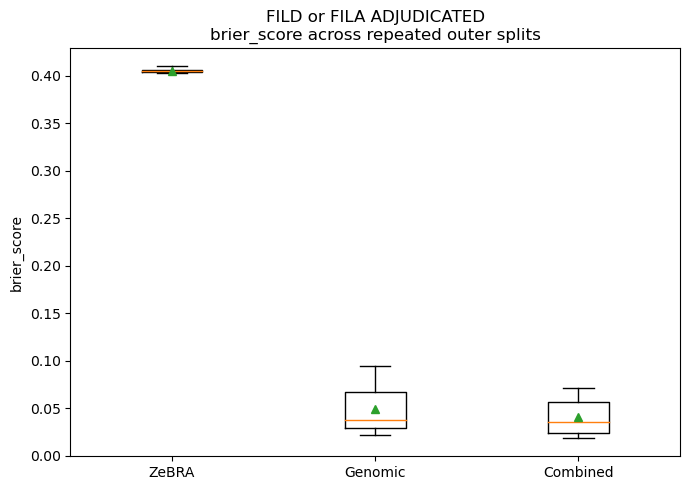

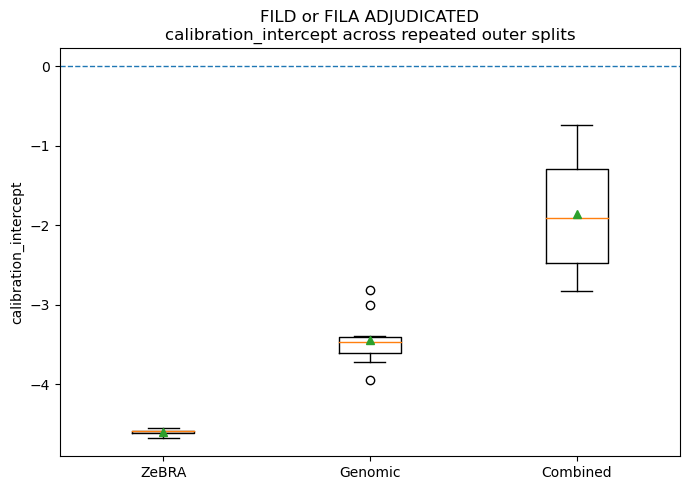

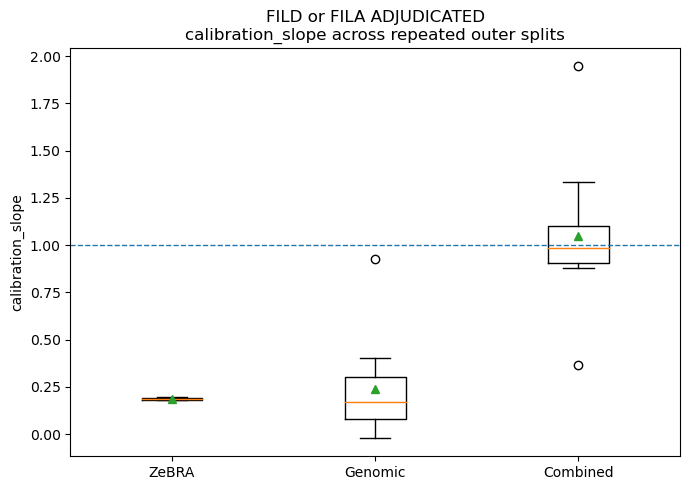

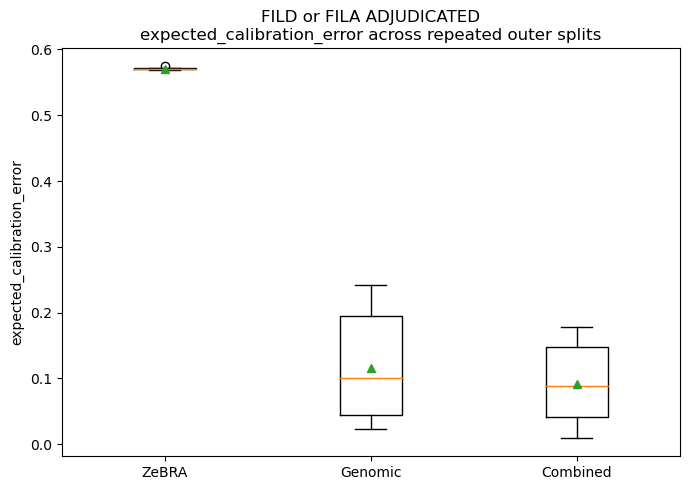

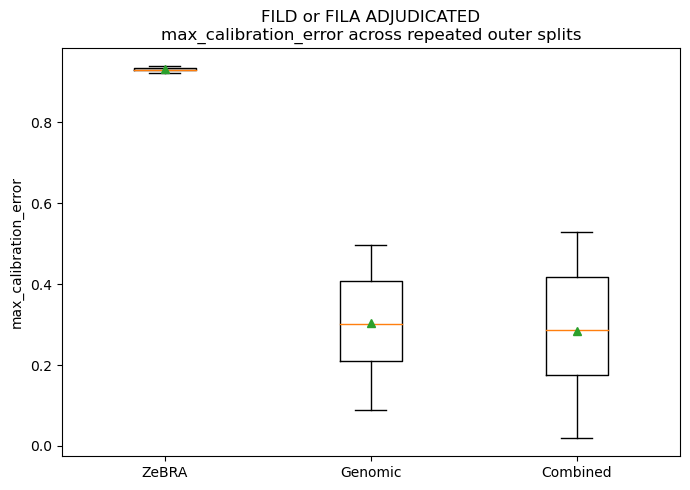

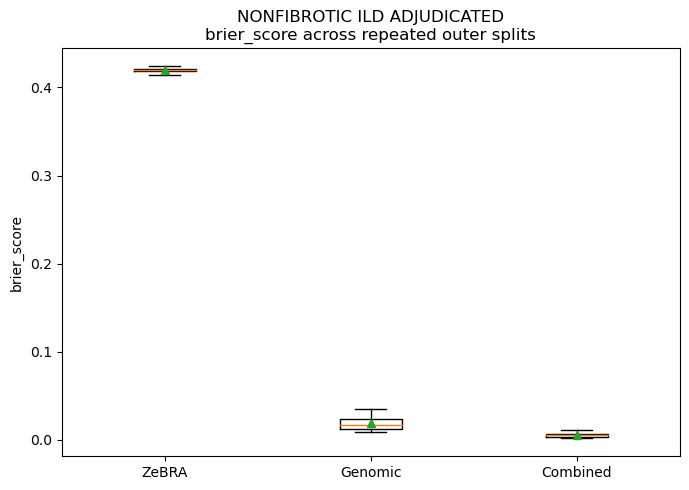

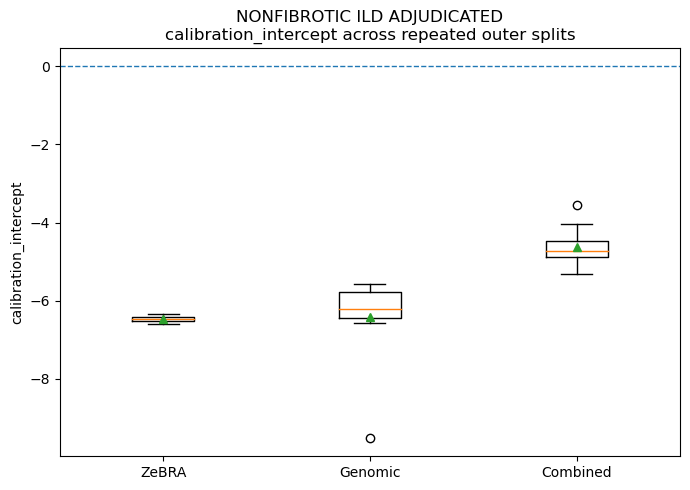

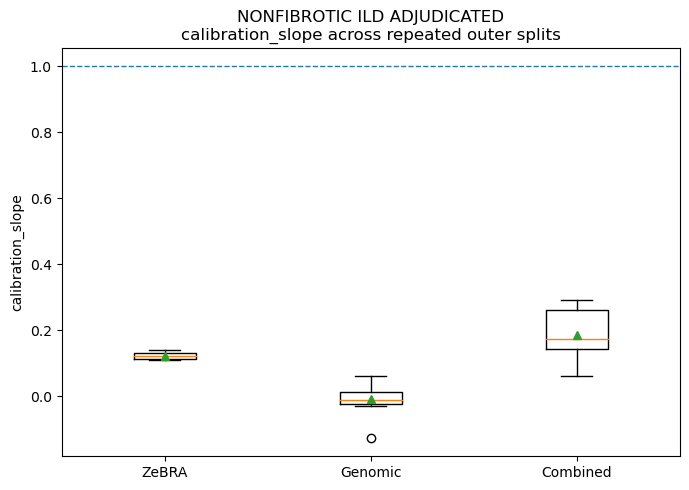

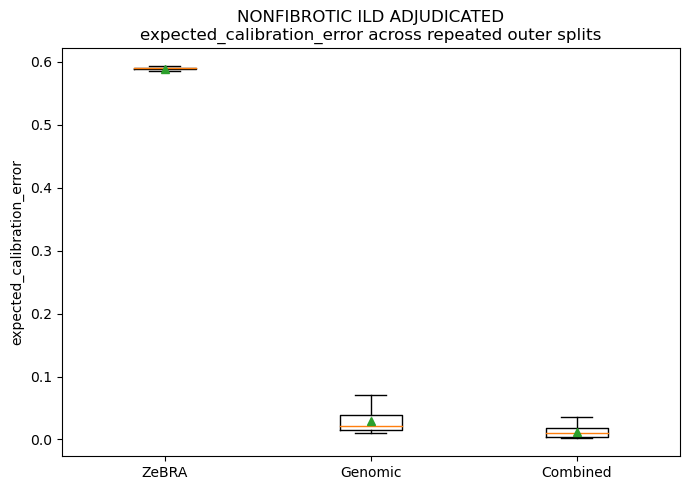

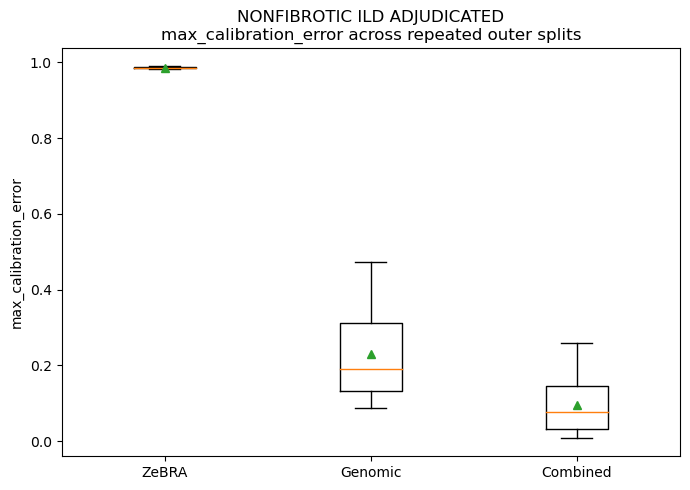

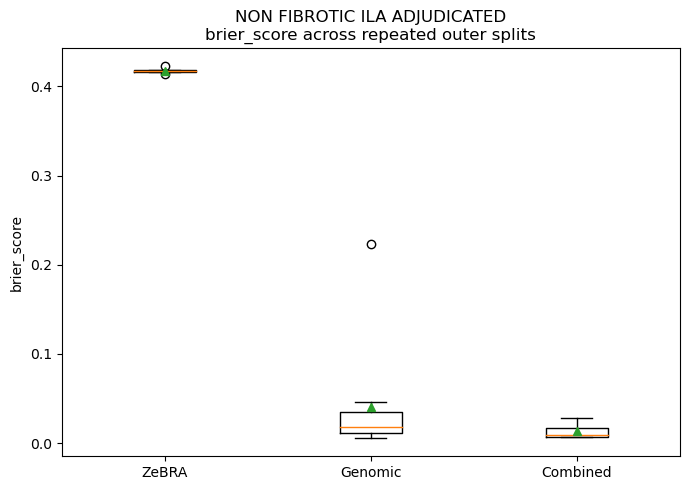

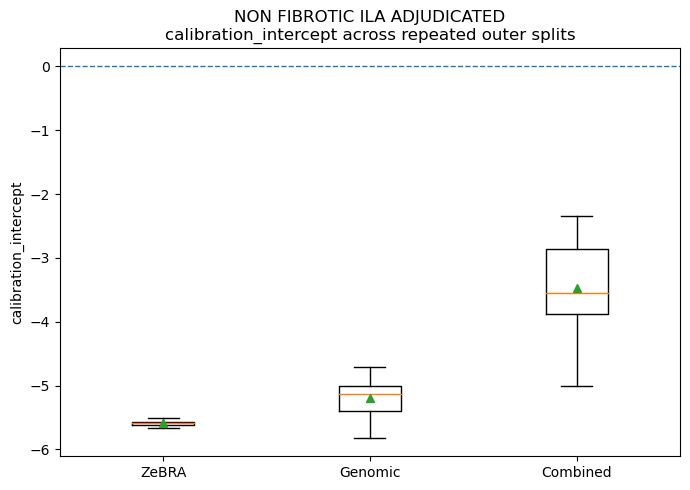

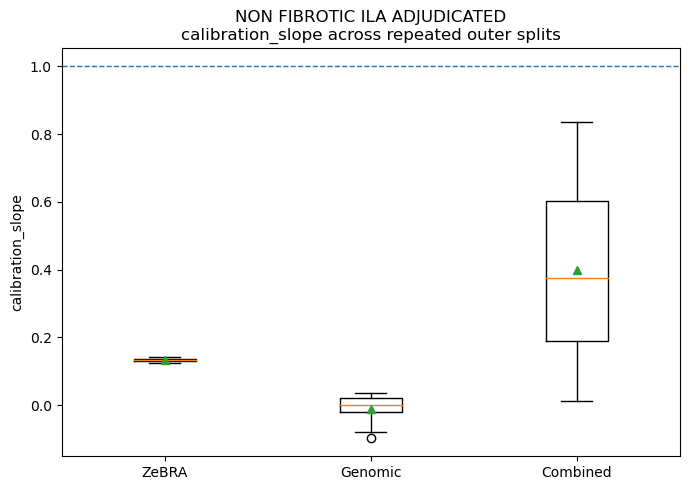

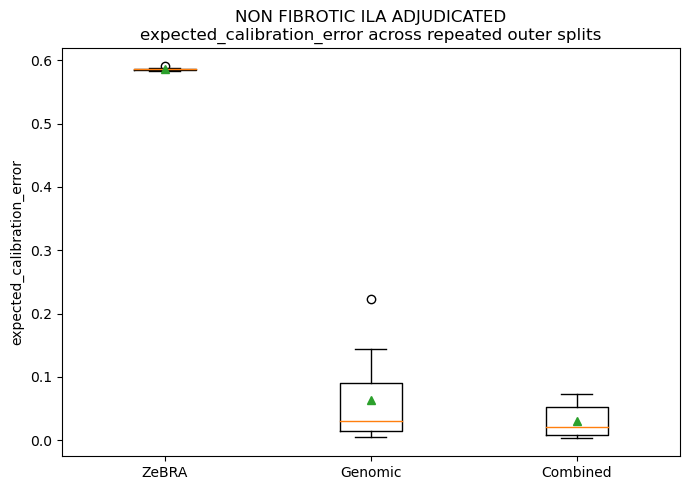

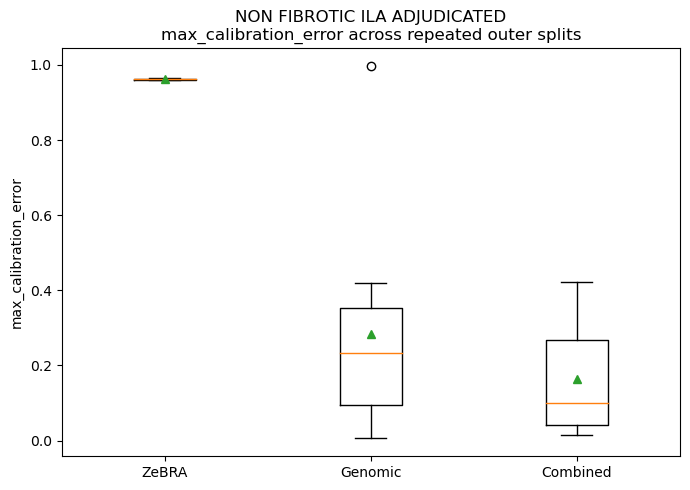

In [9]:
CAL_METRICS = [
    "brier_score",
    "calibration_intercept",
    "calibration_slope",
    "expected_calibration_error",
    "max_calibration_error",
]

for target_name in TARGET_NAMES:

    sub = ZEDSTAT_SUMMARY_DF[
        ZEDSTAT_SUMMARY_DF["target_name"]
        == target_name
    ]

    for metric in CAL_METRICS:
        fig, ax = plt.subplots(
            figsize=(7, 5)
        )

        data = [
            sub.loc[
                sub["model"] == model_name,
                metric,
            ].dropna().to_numpy()
            for model_name in [
                "zebra",
                "genomic",
                "combined",
            ]
        ]

        ax.boxplot(
            data,
            labels=[
                "ZeBRA",
                "Genomic",
                "Combined",
            ],
            showmeans=True,
        )

        if metric == "calibration_intercept":
            ax.axhline(
                0,
                linestyle="--",
                linewidth=1,
            )

        if metric == "calibration_slope":
            ax.axhline(
                1,
                linestyle="--",
                linewidth=1,
            )

        ax.set_ylabel(metric)
        ax.set_title(
            f"{target_name}\n{metric} across repeated outer splits"
        )

        fig.tight_layout()

        safe_metric = metric.replace(
            "/",
            "_",
        )

        fig.savefig(
            ROOT_OUT
            / f"calibration_{safe_metric}_{target_name}.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()


## Plot AUC distributions for all three phenotype contexts

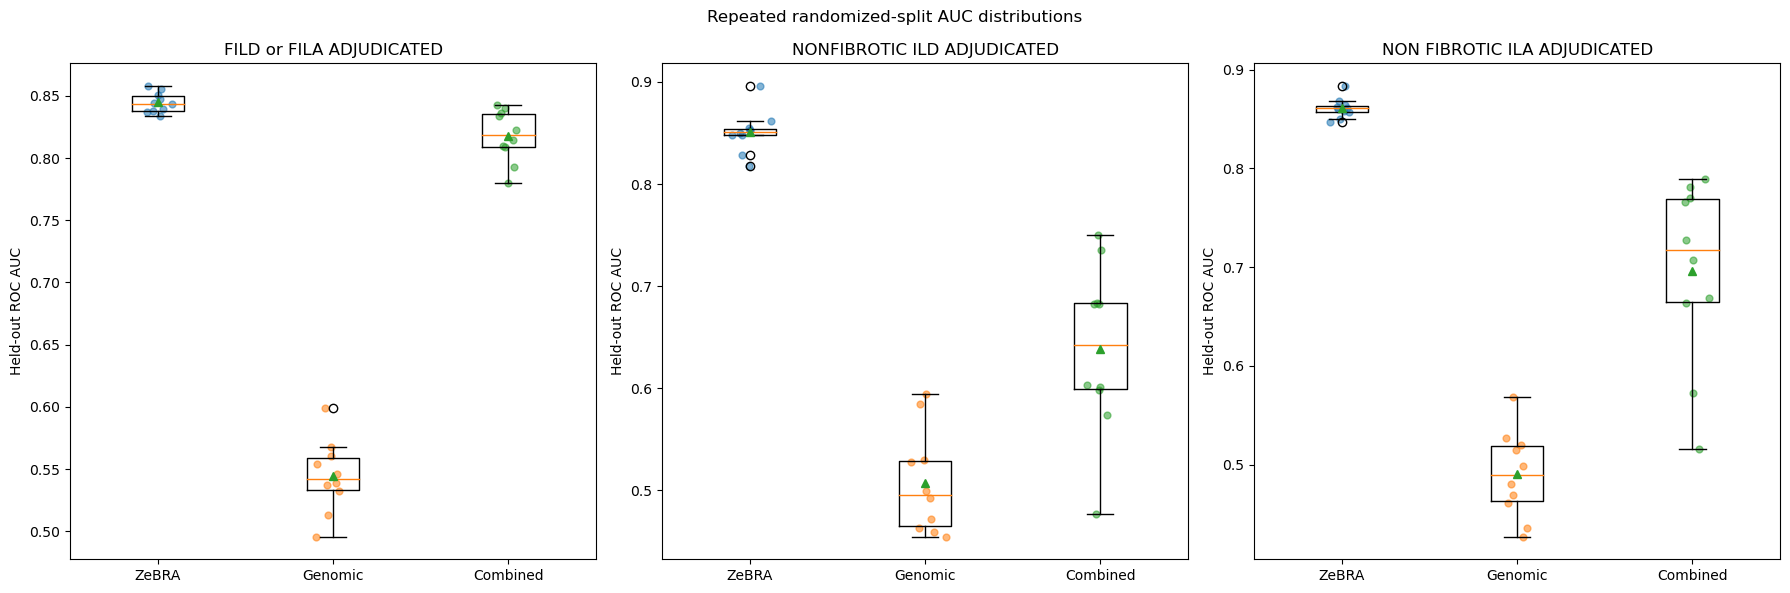

In [10]:
MODEL_ORDER = ["zebra", "genomic", "combined"]

fig, axes = plt.subplots(
    1, len(TARGET_NAMES),
    figsize=(6 * len(TARGET_NAMES), 6),
)

if len(TARGET_NAMES) == 1:
    axes = [axes]

for ax, target in zip(axes, TARGET_NAMES):
    sub = AUC_DF[AUC_DF["target_name"] == target]

    vals = [
        sub.loc[sub["model"] == m, "auc"].to_numpy()
        for m in MODEL_ORDER
    ]

    ax.boxplot(
        vals,
        labels=["ZeBRA", "Genomic", "Combined"],
        showmeans=True,
    )

    rng = np.random.default_rng()
    for j, x in enumerate(vals, 1):
        ax.scatter(
            rng.normal(j, 0.04, len(x)),
            x,
            alpha=0.55,
            s=24,
        )

    ax.set_title(target)
    ax.set_ylabel("Held-out ROC AUC")

fig.suptitle("Repeated randomized-split AUC distributions")
fig.tight_layout()
fig.savefig(
    ROOT_OUT / "auc_distributions_three_targets.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Aggregate SHAP importance across splits

In [11]:
SHAP_DF = pd.concat(ALL_SHAP, ignore_index=True)

SHAP_DF.to_csv(
    ROOT_OUT / "shap_all_targets_by_split.csv",
    index=False,
)

SHAP_SUMMARY = shap_summary(SHAP_DF)

SHAP_SUMMARY.to_csv(
    ROOT_OUT / "shap_feature_stability_summary.csv",
    index=False,
)

display(
    SHAP_SUMMARY
    .sort_values(
        ["target_name", "model", "max_importance"],
        ascending=[True, True, False],
    )
    .groupby(["target_name", "model"], group_keys=False)
    .head(20)
)

,target_name,model,feature,n_splits,mean_importance,median_importance,max_importance,empirical_q025,empirical_q975,bootstrap_mean_ci_low,bootstrap_mean_ci_high,bootstrap_max_ci_low,bootstrap_max_ci_high
3492,FILD or FILA ADJUDICATED,combined,predicted_risk,10,0.854872,0.822828,1.308131,0.594627,1.244413,0.746001,0.976581,0.867153,1.308131
2852,FILD or FILA ADJUDICATED,combined,rs35705950.1_G_2,10,0.155777,0.139378,0.346028,0.017447,0.327788,0.099000,0.212558,0.200409,0.346028
3089,FILD or FILA ADJUDICATED,combined,rs10518693_C_2,10,0.035158,0.004015,0.310051,0.000000,0.242943,0.002388,0.097143,0.008294,0.310051
2102,FILD or FILA ADJUDICATED,combined,JHU_3.77509291_C_2,10,0.029851,0.004642,0.235398,0.000000,0.190322,0.002499,0.076931,0.006443,0.235398
3437,FILD or FILA ADJUDICATED,combined,JHU_21.19723007_A_2,10,0.056354,0.033132,0.192179,0.003132,0.168319,0.027965,0.094604,0.081280,0.192179
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5219,NONFIBROTIC ILD ADJUDICATED,genomic,JHU_22.44499088_G_1,10,1.838984,0.019046,17.618381,0.000000,13.765600,0.024856,5.356713,0.208798,17.618381
4617,NONFIBROTIC ILD ADJUDICATED,genomic,rs5743894_T_2,10,2.235060,0.002360,15.502510,0.000000,13.537722,0.006601,5.335590,0.065109,15.502510
3589,NONFIBROTIC ILD ADJUDICATED,genomic,rs699240_T_0,10,1.541641,0.000000,13.890832,0.000000,11.099905,0.000938,4.319881,0.004748,13.890832
3906,NONFIBROTIC ILD ADJUDICATED,genomic,JHU_4.3267073_T_2,10,1.336165,0.000000,13.339186,0.000000,10.342924,0.000000,4.004002,0.000000,13.339186


## Plot maximum SHAP importance with bootstrap bounds

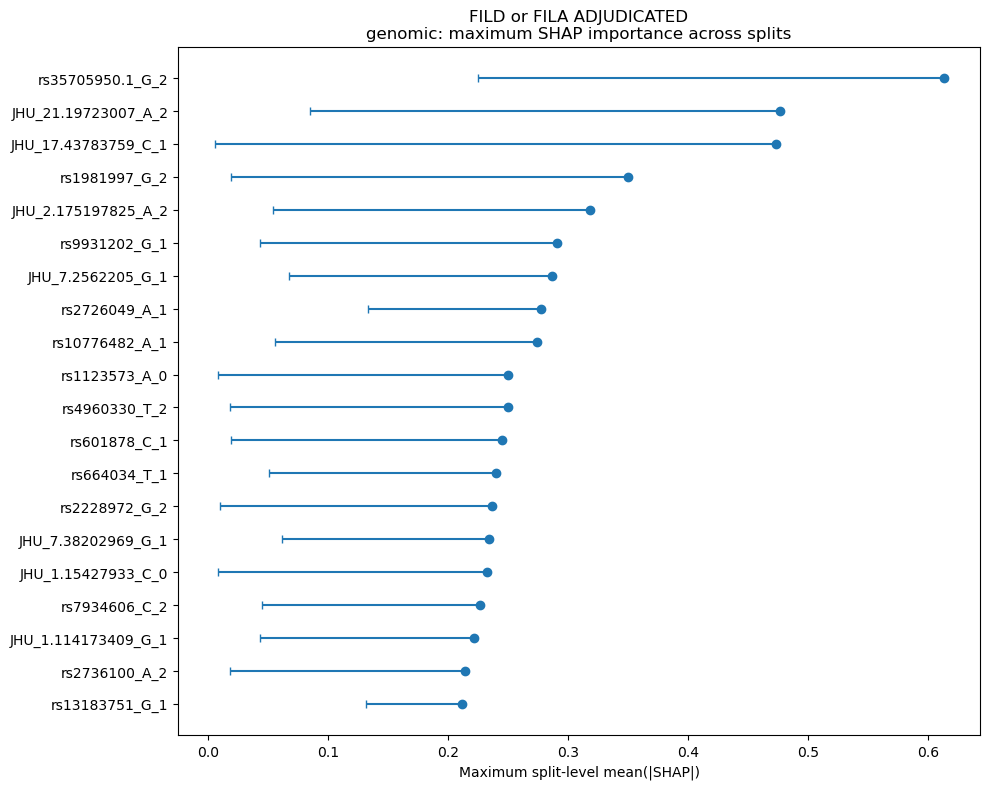

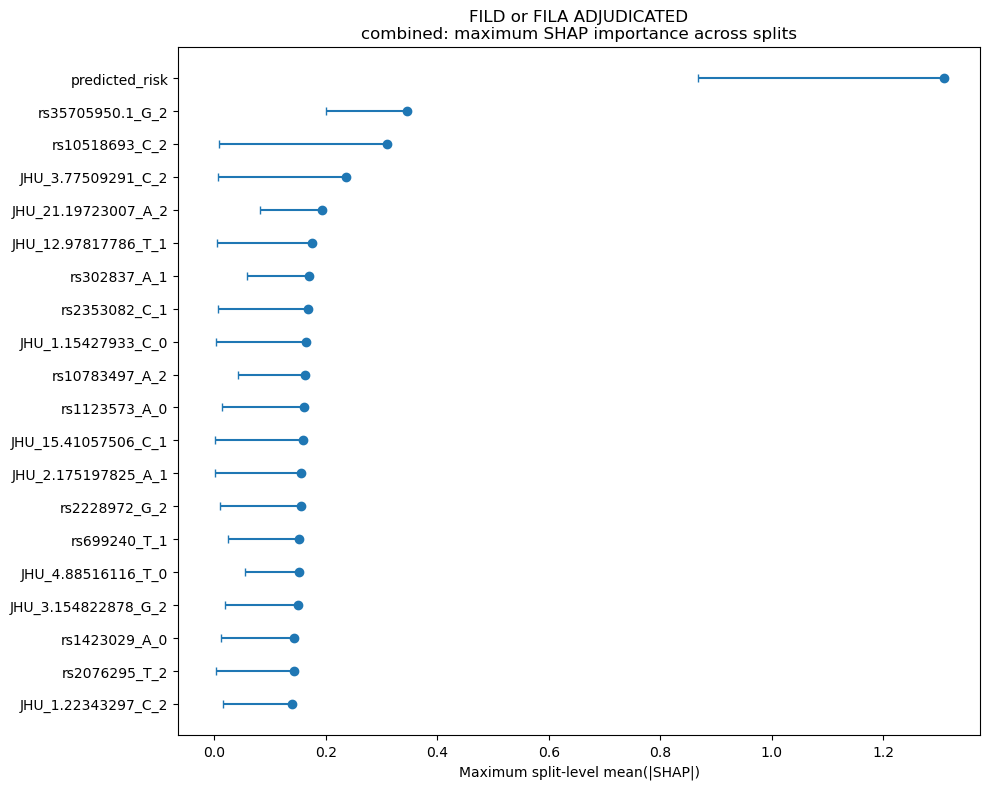

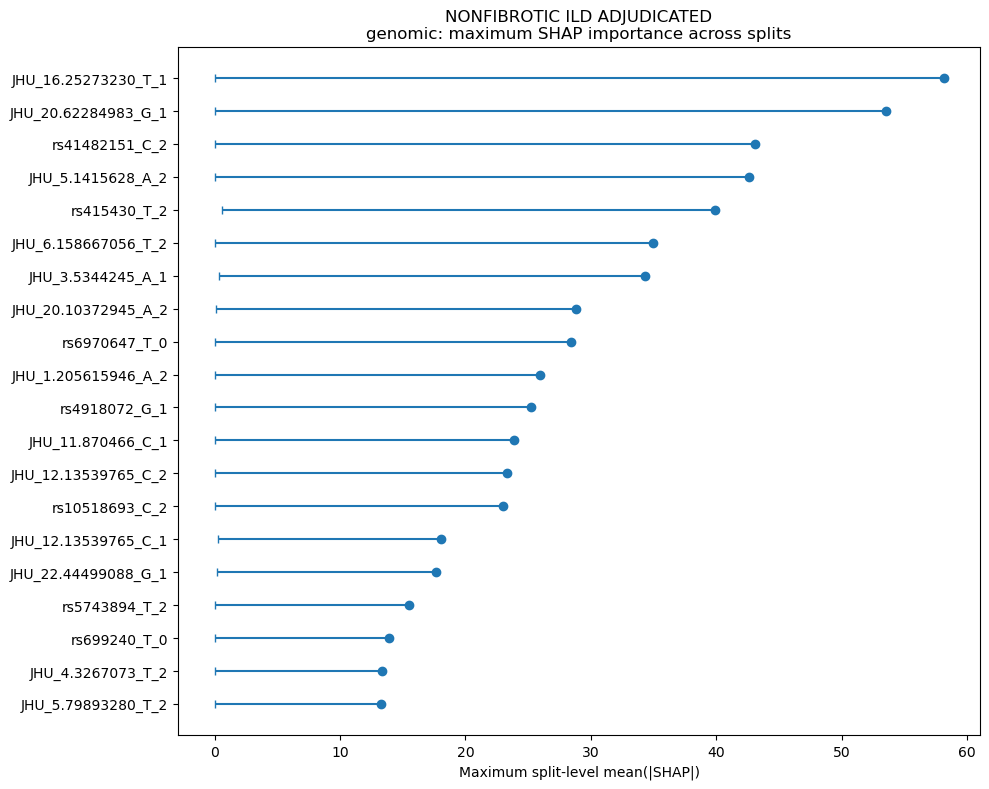

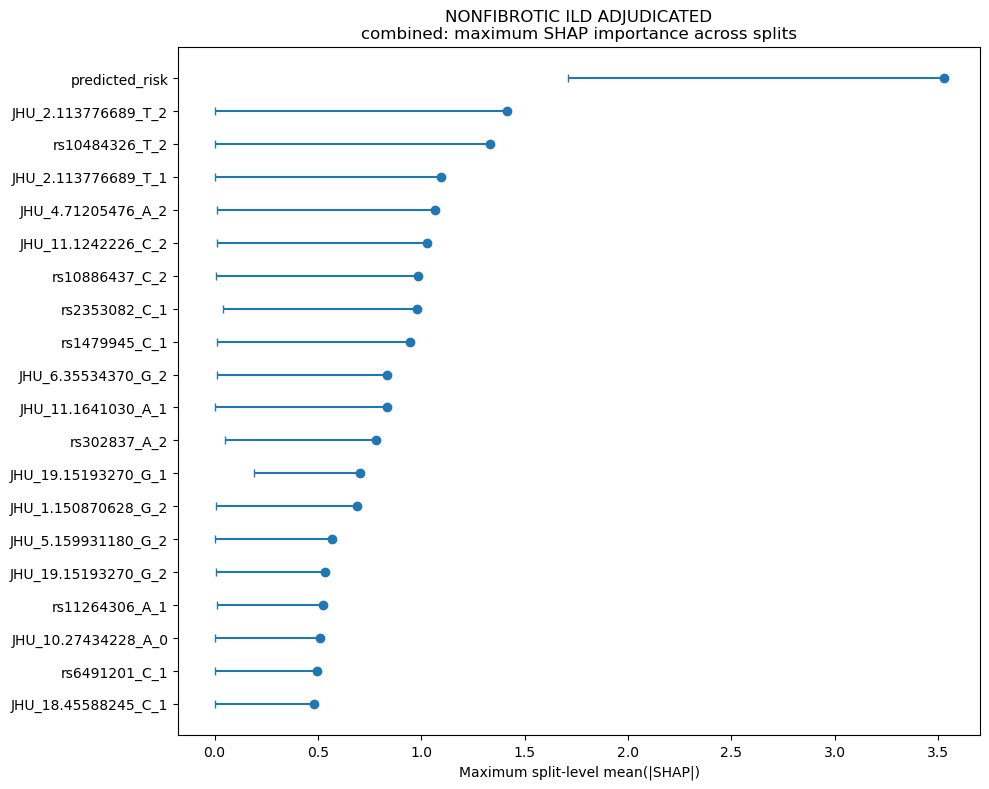

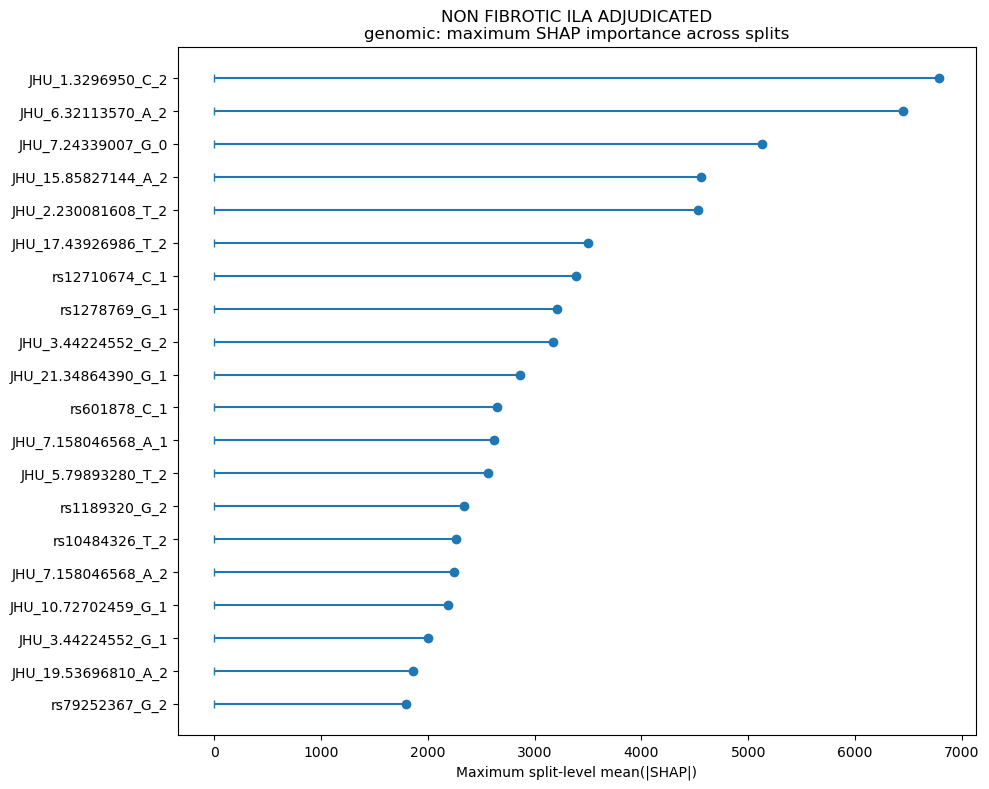

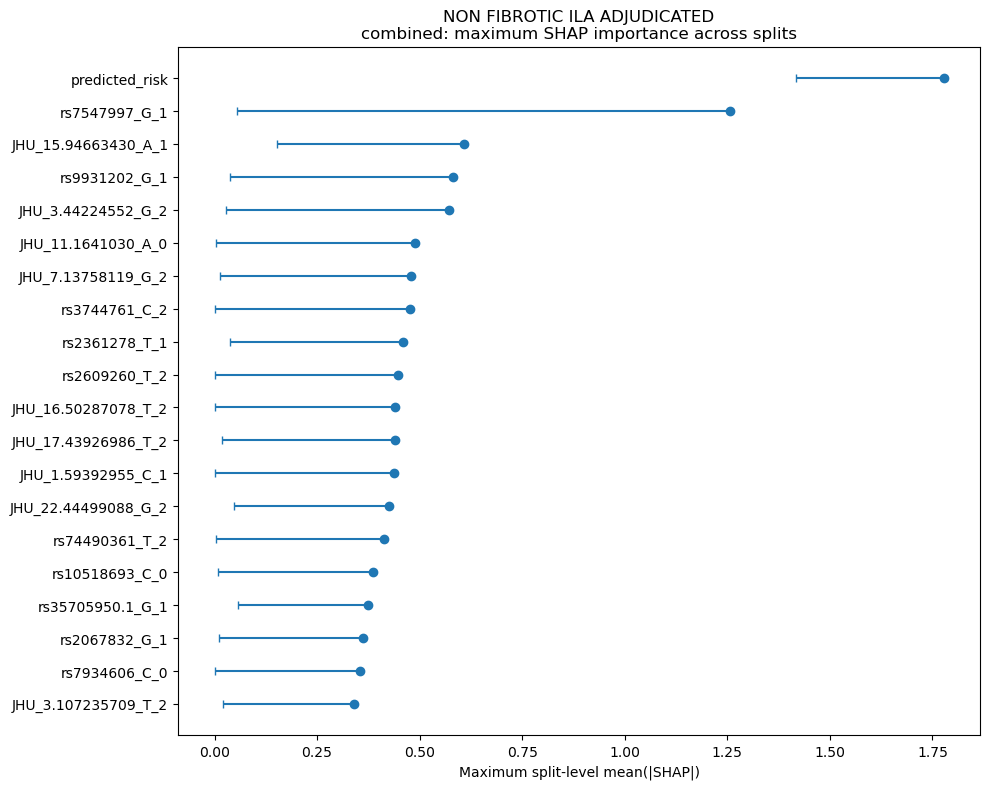

In [12]:
for target in TARGET_NAMES:
    for model in ["genomic", "combined"]:

        sub = (
            SHAP_SUMMARY[
                (SHAP_SUMMARY["target_name"] == target)
                & (SHAP_SUMMARY["model"] == model)
            ]
            .sort_values("max_importance", ascending=False)
            .head(20)
            .sort_values("max_importance")
        )

        x = sub["max_importance"].to_numpy()
        lo = sub["bootstrap_max_ci_low"].to_numpy()
        hi = sub["bootstrap_max_ci_high"].to_numpy()

        fig, ax = plt.subplots(figsize=(10, 8))

        ax.errorbar(
            x,
            np.arange(len(sub)),
            xerr=[
                np.maximum(x - lo, 0),
                np.maximum(hi - x, 0),
            ],
            fmt="o",
            capsize=3,
        )

        ax.set_yticks(np.arange(len(sub)))
        ax.set_yticklabels(sub["feature"])
        ax.set_xlabel("Maximum split-level mean(|SHAP|)")
        ax.set_title(
            f"{target}\n{model}: maximum SHAP importance across splits"
        )

        fig.tight_layout()
        fig.savefig(
            ROOT_OUT / target / f"shap_max_ci_{model}.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

## Top-20 SHAP recurrence across splits

In [13]:
ranked = SHAP_DF.copy()

ranked["rank"] = (
    ranked.groupby(
        ["target_name", "model", "repeat"]
    )["mean_abs_shap"]
    .rank(method="min", ascending=False)
)

RECURRENCE = (
    ranked[ranked["rank"] <= 20]
    .groupby(["target_name", "model", "feature"])
    .agg(
        top20_split_count=("repeat", "nunique"),
        mean_rank_when_top20=("rank", "mean"),
        max_mean_abs_shap=("mean_abs_shap", "max"),
    )
    .reset_index()
)

RECURRENCE["fraction_splits_top20"] = (
    RECURRENCE["top20_split_count"] / N_REPEATS
)

RECURRENCE.to_csv(
    ROOT_OUT / "shap_top20_recurrence.csv",
    index=False,
)

display(
    RECURRENCE
    .sort_values(
        ["target_name", "model", "fraction_splits_top20", "max_mean_abs_shap"],
        ascending=[True, True, False, False],
    )
    .groupby(["target_name", "model"], group_keys=False)
    .head(25)
)

,target_name,model,feature,top20_split_count,mean_rank_when_top20,max_mean_abs_shap,fraction_splits_top20
65,FILD or FILA ADJUDICATED,combined,predicted_risk,10,1.000000,1.308131,1.0
108,FILD or FILA ADJUDICATED,combined,rs35705950.1_G_2,9,3.555556,0.346028,0.9
102,FILD or FILA ADJUDICATED,combined,rs302837_A_1,7,10.571429,0.170026,0.7
97,FILD or FILA ADJUDICATED,combined,rs2726049_A_1,4,14.000000,0.126632,0.4
80,FILD or FILA ADJUDICATED,combined,rs1422506_G_2,4,9.250000,0.104093,0.4
...,...,...,...,...,...,...,...
867,NONFIBROTIC ILD ADJUDICATED,genomic,rs41482151_C_1,2,10.500000,2.225262,0.2
876,NONFIBROTIC ILD ADJUDICATED,genomic,rs56111559_G_1,2,8.000000,2.222869,0.2
837,NONFIBROTIC ILD ADJUDICATED,genomic,rs1123573_A_1,2,5.500000,1.684209,0.2
870,NONFIBROTIC ILD ADJUDICATED,genomic,rs4672388_T_1,2,8.000000,0.904003,0.2
